# BERT Indonesian Sentiment Analysis

#### Importing Library

In [2]:
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras import layers
# import bert
import subprocess as sp
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
import pandas as pd
import re
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
# %matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from transformers import BertTokenizer, TFBertModel,  BertConfig, BertTokenizerFast
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix

# tensorflow.keras
from tensorflow.keras.layers import Input, Dropout, Dense, Embedding, LSTM, Flatten, Conv1D, MaxPooling1D, concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.initializers import TruncatedNormal
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.metrics import CategoricalAccuracy
from tensorflow.keras.utils import to_categorical

In [3]:
# Cek run on gpu
# %tensorflow_version 2.x
import tensorflow as tf
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print('GPU device not found')
else:
    print('Found GPU at: {}'.format(device_name))
    get_gpu_memory()

GPU device not found


In [4]:
# Get GPU Memory available
def get_gpu_memory():
  _output_to_list = lambda x: x.decode('ascii').split('\n')[:-1]

  ACCEPTABLE_AVAILABLE_MEMORY = 1024
  COMMAND = "nvidia-smi --query-gpu=memory.free --format=csv"
  memory_free_info = _output_to_list(sp.check_output(COMMAND.split()))[1:]
  memory_free_values = [int(x.split()[0]) for i, x in enumerate(memory_free_info)]
  print(memory_free_values)
  return memory_free_values

### Importing Dataset

In [6]:
# Label Name
predLabel= ['Negative', 'Positive']

In [11]:
product_reviews = pd.read_csv('datasetindo/20191002-reviews.csv')
print('Data Shape: ',product_reviews.shape )

Data Shape:  (203787, 15)


In [12]:
print('Containing NULL Values: ',product_reviews.isnull().values.any())

Containing NULL Values:  True


In [13]:
# product_reviews.head()

,itemId,category,name,rating,originalRating,reviewTitle,reviewContent,likeCount,upVotes,downVotes,helpful,relevanceScore,boughtDate,clientType,retrievedDate
0,100002528,beli-harddisk-eksternal,Kamal U.,5,NaN,NaN,bagus mantap dah sesui pesanan,0,0,0,True,26.51,09 Apr 2019,androidApp,2019-10-02
1,100002528,beli-harddisk-eksternal,yofanca m.,4,NaN,NaN,"Bagus, sesuai foto",0,0,0,True,22.49,24 Sep 2017,androidApp,2019-10-02
2,100002528,beli-harddisk-eksternal,Lazada Customer,5,NaN,ok mantaaapppp barang sesuai pesanan.. good,okkkkk mantaaaaaaapppp ... goood,0,0,0,True,21.50,04 Apr 2018,androidApp,2019-10-02
3,100002528,beli-harddisk-eksternal,Lazada Customer,4,NaN,NaN,bagus sesuai,0,0,0,True,20.51,22 Sep 2017,androidApp,2019-10-02
4,100002528,beli-harddisk-eksternal,Yosep M.,5,NaN,NaN,NaN,0,0,0,True,16.01,17 Agu 2018,androidApp,2019-10-02


In [14]:
# product_reviews.describe()

,itemId,rating,originalRating,likeCount,upVotes,downVotes,relevanceScore
count,2.037870e+05,203787.000000,8.0,203787.000000,203787.000000,203787.000000,203787.000000
mean,2.836479e+08,4.603238,1.0,0.668634,0.668634,0.164638,25.097394
std,1.726207e+08,0.991164,0.0,12.192433,12.192433,2.013273,9.602434
min,6.068000e+03,1.000000,1.0,-1.000000,-1.000000,0.000000,0.960000
25%,1.600086e+08,5.000000,1.0,0.000000,0.000000,0.000000,18.010000
50%,3.541160e+08,5.000000,1.0,0.000000,0.000000,0.000000,23.510000
75%,4.147421e+08,5.000000,1.0,0.000000,0.000000,0.000000,29.670000
max,7.242170e+08,5.000000,1.0,1776.000000,1776.000000,111.000000,76.500000


In [15]:
# product_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203787 entries, 0 to 203786
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   itemId          203787 non-null  int64  
 1   category        203787 non-null  object 
 2   name            203787 non-null  object 
 3   rating          203787 non-null  int64  
 4   originalRating  8 non-null       float64
 5   reviewTitle     23404 non-null   object 
 6   reviewContent   107029 non-null  object 
 7   likeCount       203787 non-null  int64  
 8   upVotes         203787 non-null  int64  
 9   downVotes       203787 non-null  int64  
 10  helpful         203787 non-null  bool   
 11  relevanceScore  203787 non-null  float64
 12  boughtDate      196680 non-null  object 
 13  clientType      203787 non-null  object 
 14  retrievedDate   203787 non-null  object 
dtypes: bool(1), float64(2), int64(5), object(7)
memory usage: 22.0+ MB


### Clearing Null data

In [16]:
dataReview = product_reviews[['reviewContent', 'rating']]
print('Data inculding null: ',len(dataReview))
dataReview = dataReview.dropna()
print('Data without null: ',len(dataReview))

Data inculding null:  203787
Data without null:  107029


### Making synthetic label
positive sentiment for reviwe with rating higher than 3, vice versa

In [17]:
ratingToLabel = lambda x: 1 if x>3 else 0

In [18]:
# Apply function to convert rating to label
dataReview['rating'] = dataReview['rating'].apply(ratingToLabel)

In [19]:
# Convert review coloumn to text
dataReview['reviewContent'] = dataReview['reviewContent'].astype(str)

In [20]:
# dataReview.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 107029 entries, 0 to 203786
Data columns (total 2 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   reviewContent  107029 non-null  object
 1   rating         107029 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ MB


### Preprocessing Dataset
Removing noise, convert label

In [21]:
def reduce_lengthening(text):
    pattern = re.compile(r"(.)\1{2,}")
    return pattern.sub(r"\1\1", text)

def remove_tags(text):
    TAG_RE = re.compile(r'<[^>]+>')
    return TAG_RE.sub('', text)

def preprocess_text(sen):
    # Removing html tags
    sentence = remove_tags(sen)
    
    #removing overlength word
    sentence = reduce_lengthening(sen)

    # Remove punctuations and numbers
    sentence = re.sub('[^a-zA-Z]', ' ', sentence)

    # Single character removal
    sentence = re.sub(r"\s+[a-zA-Z]\s+", ' ', sentence)

    # Removing multiple spaces
    sentence = re.sub(r'\s+', ' ', sentence)

    return sentence

In [22]:
print('Preprocessing Dataset..')

Preprocessing Dataset..


In [23]:
# Start preprecoesing
reviews = []
sentences = list(dataReview['reviewContent'])
for sen in tqdm(sentences):
    reviews.append(preprocess_text(sen))

100%|██████████| 107029/107029 [00:03<00:00, 30180.06it/s]


In [24]:
print('Preprocessing Completed!')

Preprocessing Completed!


### Convert Label into numeric single dimension

In [25]:
# y = movie_reviews['sentiment']
# y = np.array(list(map(lambda x: 1 if x=="positive" else 0, y)))
y = dataReview['rating']

### Building Pre-Processed Dataset

In [26]:
dfku = pd.DataFrame(list(zip(reviews, y)), 
               columns =['review', 'label'])

### Distributing Dataset into Train and Test split

In [27]:
# R = dfku.drop(columns=['label']) #will convert into frame
R = dfku['review'] #will convert into series
L = dfku['label']

In [28]:
X_Train, X_Test, Y_Train, Y_Test = train_test_split(R,L,test_size=0.3, shuffle=True)

In [30]:
print('Training Set size: ',len(X_Train))
print('Test Set size: ',len(X_Test))
# print(len(Y_Train))
# print(len(Y_Test))

Training Set size:  74920
Test Set size:  32109


### Data Analysis
Checking Class Distribution and Review Length Distribution, and word frequency distribution

/home/athed/anaconda3/envs/ml/lib/python3.6/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


<AxesSubplot:xlabel='rating', ylabel='count'>

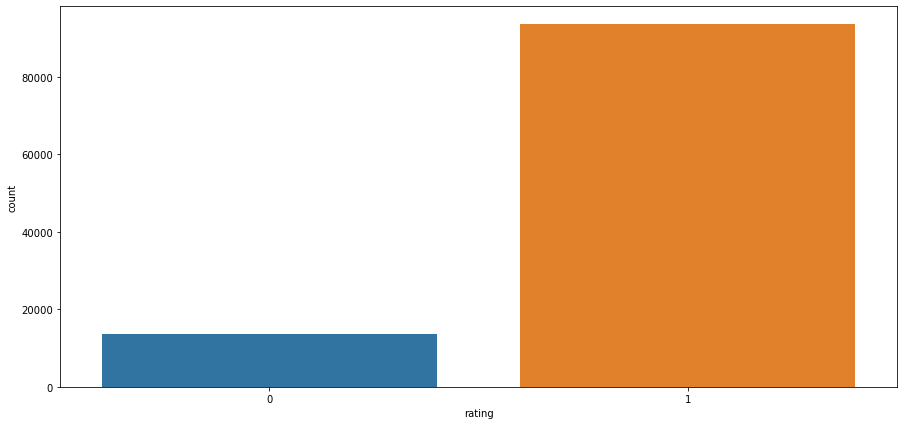

In [31]:
plt.figure(figsize=(15,7))
sns.countplot(y)

In [32]:
def getlen(rv):
    return len(rv)

In [33]:
rvlen = [getlen(R) for R in tqdm(R)]

100%|██████████| 107029/107029 [00:00<00:00, 1483085.43it/s]


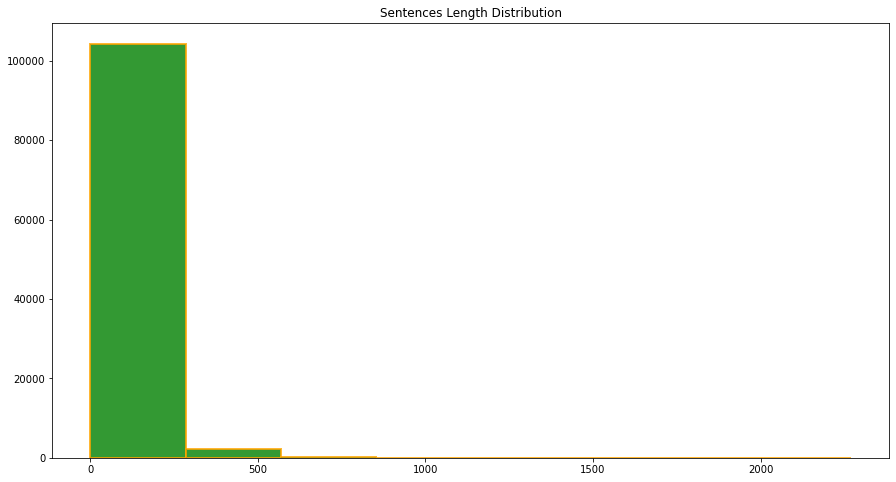

In [34]:
plt.figure(figsize=(15,8))
plt.title("Sentences Length Distribution")
n,bins,patch = plt.hist(rvlen,bins=8, color='green', alpha=0.8, label='Value', edgecolor='orange', linewidth=2)

In [35]:
#get word frequency distribution
# lw = dict(tokenizer.vocab)
# freqword = list(lw.values())

from collections import Counter
results = Counter()
dfku['review'].str.lower().str.split().apply(results.update)
wordCount = results.values()
wordCount = list(wordCount)

### According to the graph, contextual word is more dominance here

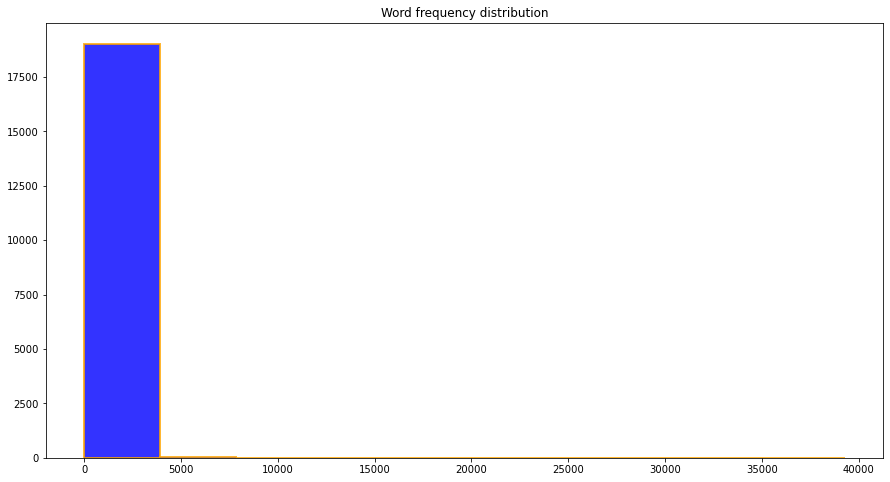

In [36]:
plt.figure(figsize=(15,8))
plt.title("Word frequency distribution")
n,bins,patch = plt.hist(wordCount,bins=10, color='blue', alpha=0.8, label='Value', edgecolor='orange', linewidth=2)

### Make One-Hot Encode Label Version

In [37]:
Ytrain = pd.get_dummies(Y_Train)
Ytest = pd.get_dummies(Y_Test)
# OR
y_trainMulti = to_categorical(Y_Train)
y_testMulti = to_categorical(Y_Test)

### BERT Tokenizer
To Transform sentence into token then ids with special token

In [38]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

In [39]:
def convertText2Ids(text):
    return tokenizer.encode_plus(
        text,
        max_length=512,
        add_special_tokens=True, # Add '[CLS]' and '[SEP]'
        return_token_type_ids=True,
        pad_to_max_length=True,
        return_attention_mask=True,
        truncation=True
    )

In [41]:
#Example
# sequence_a = "HuggingFace is based in NYC"
# sequence_b = "Where is HuggingFace based?"
# encoded_dict = tokenizer(sequence_a, sequence_b)
# encoded_dict

In [42]:
# #Example
# tokenizer.encode_plus(
#         sequence_a, sequence_b,
#         max_length=20,
#         add_special_tokens=True, # Add '[CLS]' and '[SEP]'
#         return_token_type_ids=True,
#         pad_to_max_length=True,
#         return_attention_mask=True,
#         truncation=True
#     )

### Load BERT Tokenizer

In [43]:
print('Downloading BERT Tokenizer..')

In [46]:
# BertTokenizer = None
# BertTokenizer = bert.bert_tokenization.FullTokenizer
bert_layer = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/1",
                            trainable=False)
vocabulary_file = bert_layer.resolved_object.vocab_file.asset_path.numpy()
to_lower_case = bert_layer.resolved_object.do_lower_case.numpy()
tokenizer = BertTokenizer(vocabulary_file, to_lower_case)

In [44]:
print('vocabulary size: ',len(tokenizer.vocab))

vocabulary size:  30522


### Applying BERT into Training and Test Data

In [36]:
def textToToken(text):
    #Train Data
    return tokenizer(
        text=text,
        add_special_tokens=True,
        max_length=200,
        truncation=True,
        padding='max_length', 
        return_tensors='tf',
        return_token_type_ids = False,
        return_attention_mask = True,
        verbose = True
    )

In [37]:
print('Tokenizing Train Data...')
#Train Data
trainBert = tokenizer(
    text=X_Train.tolist(),
    add_special_tokens=True,
    max_length=200,
    truncation=True,
    padding='max_length', 
    return_tensors='tf',
    return_token_type_ids = False,
    return_attention_mask = True,
    verbose = True)

Tokenizing Train Data...


In [38]:
#Test Data
testBert = tokenizer(
    text=X_Test.tolist(),
    add_special_tokens=True,
    max_length=200,
    truncation=True,
    padding='max_length', 
    return_tensors='tf',
    return_token_type_ids = False,
    return_attention_mask = True,
    verbose = True)

print('Tokenizing Complete!')

Tokenizing Complete!


### Model Parameter

In [47]:
# model parameter
VOCAB_LENGTH = len(tokenizer.vocab)
EMB_DIM = 200
CNN_FILTERS = 100
DNN_UNITS = 256
OUTPUT_CLASSES = 2
DROPOUT_RATE = 0.2
NB_EPOCHS = 5

# Building TensorFlow Model 1
Single Input (Token ids)

Model 1 require single label format instead of one-hot encoding

In [39]:
class TEXT_MODEL(tf.keras.Model):
    
    def __init__(self,
                 vocabulary_size,
                 embedding_dimensions=128,
                 cnn_filters=50,
                 dnn_units=512,
                 model_output_classes=2,
                 dropout_rate=0.1,
                 training=False,
                 name="text_model"):
        super(TEXT_MODEL, self).__init__(name=name)
        
        self.embedding = layers.Embedding(vocabulary_size,
                                          embedding_dimensions)
        self.cnn_layer1 = layers.Conv1D(filters=cnn_filters,
                                        kernel_size=2,
                                        padding="valid",
                                        activation="relu")
        self.cnn_layer2 = layers.Conv1D(filters=cnn_filters,
                                        kernel_size=3,
                                        padding="valid",
                                        activation="relu")
        self.cnn_layer3 = layers.Conv1D(filters=cnn_filters,
                                        kernel_size=4,
                                        padding="valid",
                                        activation="relu")
        self.pool = layers.GlobalMaxPool1D()
        self.dense_1 = layers.Dense(units=dnn_units, activation="relu")
        self.dropout = layers.Dropout(rate=dropout_rate)
        if model_output_classes == 2:
            self.last_dense = layers.Dense(units=1,
                                           activation="sigmoid")
        else:
            self.last_dense = layers.Dense(units=model_output_classes,
                                           activation="softmax")
    
    def call(self, inputs, training):
        l = self.embedding(inputs)
        l_1 = self.cnn_layer1(l) 
        l_1 = self.pool(l_1) 
        l_2 = self.cnn_layer2(l) 
        l_2 = self.pool(l_2)
        l_3 = self.cnn_layer3(l)
        l_3 = self.pool(l_3) 
        
        concatenated = tf.concat([l_1, l_2, l_3], axis=-1) # (batch_size, 3 * cnn_filters)
        concatenated = self.dense_1(concatenated)
        concatenated = self.dropout(concatenated, training)
        model_output = self.last_dense(concatenated)
        
        return model_output

In [41]:
# create model
text_model = None
text_model = TEXT_MODEL(vocabulary_size=VOCAB_LENGTH,
                        embedding_dimensions=EMB_DIM,
                        cnn_filters=CNN_FILTERS,
                        dnn_units=DNN_UNITS,
                        model_output_classes=OUTPUT_CLASSES,
                        dropout_rate=DROPOUT_RATE)

In [42]:
# compile model
if OUTPUT_CLASSES == 2:
    text_model.compile(loss="binary_crossentropy",
                       optimizer="adam",
                       metrics=["accuracy"])
else:
    text_model.compile(loss="sparse_categorical_crossentropy",
                       optimizer="adam",
                       metrics=["sparse_categorical_accuracy"])

In [43]:
# trainBert['input_ids'].shape
# text_model.build((None,200))

In [44]:
# y_trainkuu = np.asarray(dataLabel).astype('float32').reshape((-1,1))

### Start Model 1 Training

In [45]:
# history = text_model.fit(x=trainBert['input_ids'], y=Y_Train, 
#                          epochs=NB_EPOCHS, 
#                          alidation_data=(testBert['input_ids'],Y_Test), 
#                          callbacks=[tensorboard,earlystop,checkpoint], verbose=2)

# history = text_model.fit(x={'input_ids': trainBert['input_ids']}, y=Y_Train, 
#                          epochs=NB_EPOCHS, 
#                          alidation_data=(testBert['input_ids'],Y_Test), verbose=2)

csv_logger = tf.keras.callbacks.CSVLogger('TFmodel1Training.csv')
print('Traning TensorFlow Model 1 Please Wait...')
history = text_model.fit(x=trainBert['input_ids'], y=Y_Train, 
                         epochs=NB_EPOCHS, callbacks=[csv_logger],
                         validation_data=(testBert['input_ids'],Y_Test), verbose=2)
print('Traning TensorFlow Model 1 Completed!')

Traning TensorFlow Model 1 Please Wait...
Epoch 1/5
2342/2342 - 176s - loss: 0.1991 - accuracy: 0.9247 - val_loss: 0.1553 - val_accuracy: 0.9475
Epoch 2/5
2342/2342 - 173s - loss: 0.1113 - accuracy: 0.9639 - val_loss: 0.1159 - val_accuracy: 0.9629
Epoch 3/5
2342/2342 - 177s - loss: 0.0665 - accuracy: 0.9795 - val_loss: 0.1084 - val_accuracy: 0.9694
Epoch 4/5
2342/2342 - 175s - loss: 0.0480 - accuracy: 0.9853 - val_loss: 0.1109 - val_accuracy: 0.9717
Epoch 5/5
2342/2342 - 175s - loss: 0.0385 - accuracy: 0.9878 - val_loss: 0.1055 - val_accuracy: 0.9751
Traning TensorFlow Model 1 Completed!


In [46]:
# Subclassed Model only can be saved using this code, saving using 'tf' format
print('Saving Model..')
tf.saved_model.save(text_model,'Model/TFmodel1')

Saving Model..
Instructions for updating:
This property should not be used in TensorFlow 2.0, as updates are applied automatically.


Instructions for updating:
This property should not be used in TensorFlow 2.0, as updates are applied automatically.


Instructions for updating:
This property should not be used in TensorFlow 2.0, as updates are applied automatically.


Instructions for updating:
This property should not be used in TensorFlow 2.0, as updates are applied automatically.


INFO:tensorflow:Assets written to: TFmodel1/assets


INFO:tensorflow:Assets written to: TFmodel1/assets


In [47]:
# Loading 'tf' format model
# aku = tf.saved_model.load('tes') #no architecture
# loadedmodel1 = tf.keras.models.load_model('tes') #recommended

In [48]:
# text_model.summary()

Model: "text_model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        multiple                  6104400   
_________________________________________________________________
conv1d (Conv1D)              multiple                  40100     
_________________________________________________________________
conv1d_1 (Conv1D)            multiple                  60100     
_________________________________________________________________
conv1d_2 (Conv1D)            multiple                  80100     
_________________________________________________________________
global_max_pooling1d (Global multiple                  0         
_________________________________________________________________
dense (Dense)                multiple                  77056     
_________________________________________________________________
dropout (Dropout)            multiple                  0

### Running Batch Predict

In [49]:
#Batch Prediction
ypredku = text_model.predict(testBert['input_ids'])

In [51]:
#justify prediction probability
justifypred = lambda x: 1 if x>0.5 else 0
ypred = [justifypred(x) for x in tqdm(ypredku)]

100%|██████████| 32109/32109 [00:00<00:00, 467783.63it/s]


In [52]:
# pl = [predLabel[x] for x in tqdm(ypred[0:10])]
# print('Prediction Result: ',pl)

100%|██████████| 10/10 [00:00<00:00, 17476.27it/s]

Prediction Result:  ['Positive', 'Positive', 'Positive', 'Positive', 'Positive', 'Positive', 'Positive', 'Negative', 'Negative', 'Positive']


### Running Single Data Prediction

In [ ]:
# query = str(input('Write some sentence: '))
# query = textToToken(query)

# # Add data dimension, model require input shape (1,200) 
# # addDimen = np.expand_dims(trainBerttessss['input_ids'], axis=0)

# #predict
# singlePred = text_model.predict(query['input_ids'])
# print('Sentiment Prediction: ',predLabel[justifypred(singlePred)])

Write some sentence: I Love this product
Sentiment Prediction:  Positive


# Plotting Model Performance
Confussion Matrix, precision, recall, f1-score, and support, Fitting

In [80]:
#Plotting COnfusion Matrix
def plot_confusion_matrix(cm,
                          target_names,
                          title='Confusion matrix',
                          cmap=None,
                          normalize=True):

    import itertools
    accuracy = np.trace(cm) / float(np.sum(cm))
    misclass = 1 - accuracy

    if cmap is None:
        cmap = plt.get_cmap('Blues')

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    if target_names is not None:
        tick_marks = np.arange(len(target_names))
        plt.xticks(tick_marks, target_names, rotation=45)
        plt.yticks(tick_marks, target_names)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 1.5 if normalize else cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        if normalize:
            plt.text(j, i, "{:0.4f}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
        else:
            plt.text(j, i, "{:,}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")


    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label\naccuracy={:0.4f}; misclass={:0.4f}'.format(accuracy, misclass))
    plt.show()

## Model 1

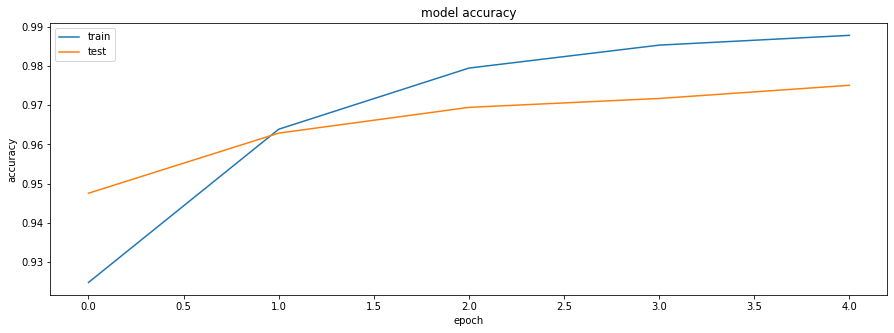

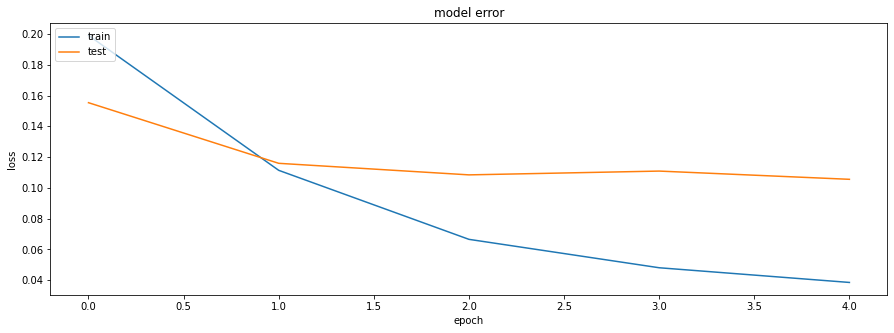

[[ 3461   572]
 [  228 27848]]
              precision    recall  f1-score   support

    Negative       0.94      0.86      0.90      4033
    Positive       0.98      0.99      0.99     28076

    accuracy                           0.98     32109
   macro avg       0.96      0.93      0.94     32109
weighted avg       0.97      0.98      0.97     32109



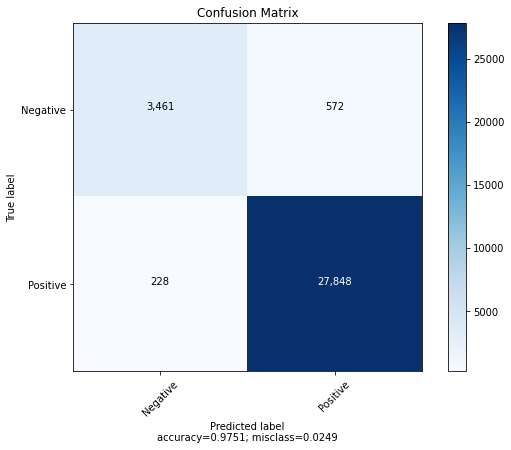

In [89]:
plt.figure(figsize=(15,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

plt.figure(figsize=(15,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model error')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

yTrue = Y_Test.tolist()
target_names = ['Negative', 'Positive']
print(confusion_matrix(yTrue, ypred))
print(classification_report(yTrue, ypred, target_names=target_names))

plot_confusion_matrix(cm           = confusion_matrix(yTrue, ypred), 
                      normalize    = False,
                      target_names = target_names,
                      title        = "Confusion Matrix")



In [ ]:
print('Training Finished!')